# Multi-genre natural language inference(MNLI)
---


MNLI는 두 문장이 주어졌을 때 논리적으로 연결이 되어 있는지, 서로 모순되는지, 아니면 아예 무관한지 분류하는 문제입니다.

- 감정 분석과 같은 sentence classification이지만 문장이 두 개 주어집니다.
- 진행 가이드 (dataset - kaggle 사용법 가이드 포함)
    - **입력**: premise에 해당하는 문장과 hypothesis에 해당하는 문장 두 개가 입력으로 들어옵니다.
    - **출력:** 분류 문제로, 두 문장이 들어왔을 때 다음 세 가지를 예측하시면 됩니다.
        - **Entailment:** 두 문장에 논리적 모순이 없습니다.
        - **Neutral:** 두 문장은 논리적으로 관련이 없습니다.
        - **Contradiction:** 두 문장 사이에 논리적 모순이 존재합니다.
    - Train과 test data는 [이 링크](https://www.kaggle.com/datasets/thedevastator/unlocking-language-understanding-with-the-multin)의 data를 활용하시면 됩니다.
         
        ```python
        import kagglehub
        
        # Download latest version
        path = kagglehub.dataset_download("thedevastator/unlocking-language-understanding-with-the-multin")
        
        print("Path to dataset files:", path)
        ```
        
    - Test data는 `validation_matched.csv`를 활용하시면 되고, colab으로 불러오는 것은 다음 코드를 참조해주시면 됩니다:
        
        ```
        import random
        import pandas as pd
        
        def load_data(path, nrows=None):
          df = pd.read_csv(path, nrows=nrows, keep_default_na=False)
          data = []
          for _, row in df.iterrows():
            if len(row['premise']) * len(row['hypothesis']) != 0:
              data.append({'premise': row['premise'], 'hypothesis': row['hypothesis'], 'label': row['label']})
        
          return data
        
        # 경로 : load_data(path + '/불러올파일명.csv', nrows=1000)
        train_data = load_data(path+'/train.csv', nrows=1000)
        test_data = load_data(path+'/validation_matched.csv', nrows=1000)
        ```

# 1단계: 필요한 라이브러리 설치
MNLI 문제를 해결하기 위해 필요한 라이브러리를 설치.



In [ ]:
# !pip install tqdm boto3 requests regex sentencepiece sacremoses datasets
!pip install kagglehub pandas tqdm boto3 requests regex sentencepiece sacremoses datasets transformers torch
!pip install huggingface_hub[hf_xet]

# STEP1: 타깃 데이터 로드 및 도메인 특징 확인
---


In [5]:
# %load_ext cudf.pandas  # Pandas API를 cuDF를 사용하여 GPU 가속
import cudf
import kagglehub
import pandas as pd


# Kaggle에서 데이터셋 다운로드
path = kagglehub.dataset_download("thedevastator/unlocking-language-understanding-with-the-multin")

# 데이터 로드 함수 정의
def load_data(path, nrows=None):
    df = cudf.read_csv(path, nrows=nrows, keep_default_na=False) # cuDF를 사용하여 데이터 로드
    data = []
    for _, row in df.to_pandas().iterrows():  # cuDF DataFrame을 pandas DataFrame으로 변환하여 iterrows() 사용
        if len(row['premise']) * len(row['hypothesis']) != 0:
            data.append({'premise': row['premise'], 'hypothesis': row['hypothesis'], 'label': row['label']})
    return data

# 데이터 로드
train_data = load_data(path+'/train.csv', nrows=1000)
test_data = load_data(path+'/validation_matched.csv', nrows=1000)


In [6]:
"데이터셋 확인"
display(pd.DataFrame(train_data))

"라벨 유형 확인"
print(f"=========LABLE'S UNIQUE=========")
display(pd.DataFrame(train_data)['label'].unique())

,premise,hypothesis,label
0,Conceptually cream skimming has two basic dime...,Product and geography are what make cream skim...,1
1,you know during the season and i guess at at y...,You lose the things to the following level if ...,0
2,One of our number will carry out your instruct...,A member of my team will execute your orders w...,0
3,How do you know? All this is their information...,This information belongs to them.,0
4,yeah i tell you what though if you go price so...,The tennis shoes have a range of prices.,1
...,...,...,...
995,so let's see what well what kind of music do y...,Tell me about all the music you love listening...,2
996,"They--hey, what's that?"" He was looking up, a...","He looked down at the ground, while Hanson loo...",2
997,Or does cold iron ruin your conjuring here? S...,Sather Karf has no questions regarding cold ir...,2
998,5 million Americans living in households with ...,5 millun Americans make too much money,2


=========LABLE'S UNIQUE=========


array([1, 0, 2])

### * PREMISE(전제)와 HYPOTHESIS(가설)
---

MNLI (Multi-genre Natural Language Inference) 문제에서 이 두 가지는 다음과 같은 역할을 합니다.

PREMISE: 주어진 주장이나 문맥을 나타내는 문장입니다.
HYPOTHESIS: 전제를 바탕으로 추론하거나 주장하는 문장입니다.
MNLI 모델은 전제와 가설 사이의 관계를 분석하여 다음 세 가지 중 하나로 분류합니다.

- **Entailment: 전제가 가설을 논리적으로 함의하는 경우(모순이 없는 경우)** = 0
- **Neutral: 전제와 가설이 논리적으로 관련이 없는 경우** = 1
- **Contradiction: 전제와 가설이 논리적으로 모순되는 경우** = 2

예시)

PREMISE: 고양이가 쥐를 잡았다.
HYPOTHESIS: 고양이가 동물을 잡았다.
이 경우, 전제가 가설을 함의하므로 Entailment 관계입니다.

# STEP2: 데이터 전처리
---


In [7]:
from transformers import AutoTokenizer
from datasets import Dataset
import pandas as pd

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# 데이터 전처리 함수 정의
def preprocess_function(examples):
    # 토크나이징
    tokenized_examples = tokenizer(
                                   examples['premise'],
                                   examples['hypothesis'],
                                   truncation=True,
                                   padding='max_length',
                                   max_length=128
                          )
    # label 추가
    tokenized_examples['labels'] = examples['label']
    return tokenized_examples

# 데이터셋에 전처리 함수 적용
train_dataset = Dataset.from_pandas(pd.DataFrame(train_data)).map(preprocess_function, batched=True)
test_dataset = Dataset.from_pandas(pd.DataFrame(test_data)).map(preprocess_function, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

# STEP3. STUDY Direction
---

### Pre-trained 모델과 Non-pre-trained 모델 비교
- Pre-trained 모델을 fine-tuning하는 것과 pre-trained 되지 않은 모델로 학습하는 것의 차이를 비교 분석하는 방법을 제시합니다.
- 비교 항목은 train/test loss curve, accuracy plot, generalization 성능, BLEU score 등을 포함합니다.

|

1. 모델 준비:

- Pre-trained 모델: AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3) 와 같이 pre-trained 모델을 로드합니다.
- Non-pre-trained 모델: AutoModelForSequenceClassification.from_config(config) 와 같이 config를 사용하여 새로운 모델을 생성합니다. 여기서 config는 AutoConfig.from_pretrained('bert-base-uncased', num_labels=3) 와 같이 pre-trained 모델의 config를 사용할 수 있습니다.

2. 학습 및 평가:

- 두 모델을 동일한 데이터셋과 학습 설정으로 학습합니다.
학습 중 train/test loss와 accuracy를 기록합니다.
- 학습 후 test 데이터셋에서 두 모델의 성능을 평가합니다.
- MNLI의 경우 accuracy를 사용하고, BLEU score는 기계 번역과 같은 task에 적용 가능합니다.

3. 결과 비교:

- Loss Curve: Matplotlib 또는 Seaborn을 사용하여 pre-trained 및 non-pre-trained 모델의 train/test loss curve를 시각화합니다.
- Accuracy Plot: Matplotlib 또는 Seaborn을 사용하여 - pre-trained 및 non-pre-trained 모델의 train/test accuracy plot을 시각화합니다.
- Generalization 성능: Test 데이터셋에서 두 모델의 accuracy를 비교하여 generalization 성능을 평가합니다.
- BLEU Score (선택 사항): 기계 번역 task의 경우, BLEU score를 계산하여 두 모델의 성능을 비교합니다. sacrebleu 라이브러리를 사용하여 BLEU score를 계산할 수 있습니다.


In [11]:
from sklearn.metrics import accuracy_score, f1_score


# -------------------------------
# 1. 정확도 평가 함수 정의
# -------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {"accuracy": acc, "f1": f1}



In [12]:
from transformers import AutoModelForSequenceClassification, AutoConfig, TrainingArguments, Trainer
import os
os.environ["WANDB_DISABLED"] = "true"


# -------------------------------
# 2. 모델 정의
# -------------------------------
pre_trained_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
config = AutoConfig.from_pretrained('bert-base-uncased', num_labels=3)
non_pre_trained_model = AutoModelForSequenceClassification.from_config(config)

# -------------------------------
# 3. 학습 설정
# -------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_strategy='steps',
    logging_steps=10,
    evaluation_strategy="epoch",
)

# -------------------------------
# 4. Trainer 정의 (with compute_metrics)
# -------------------------------
pre_trained_trainer = Trainer(
    model=pre_trained_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

non_pre_trained_trainer = Trainer(
    model=non_pre_trained_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# -------------------------------
# 5. 학습 수행
# -------------------------------
pre_trained_trainer.train()
non_pre_trained_trainer.train()

# -------------------------------
# 6. Generalization 성능 출력
# -------------------------------
print("[Pre-trained BERT]")
train_metrics_pre = pre_trained_trainer.evaluate(train_dataset)
test_metrics_pre = pre_trained_trainer.evaluate(test_dataset)
print(f"Train Accuracy: {train_metrics_pre['eval_accuracy']:.4f}")
print(f"Test Accuracy : {test_metrics_pre['eval_accuracy']:.4f}")
print(f"Generalization Gap: {test_metrics_pre['eval_accuracy'] - train_metrics_pre['eval_accuracy']:.4f}\n")

print("[Non-pre-trained BERT]")
train_metrics_non = non_pre_trained_trainer.evaluate(train_dataset)
test_metrics_non = non_pre_trained_trainer.evaluate(test_dataset)
print(f"Train Accuracy: {train_metrics_non['eval_accuracy']:.4f}")
print(f"Test Accuracy : {test_metrics_non['eval_accuracy']:.4f}")
print(f"Generalization Gap: {test_metrics_non['eval_accuracy'] - train_metrics_non['eval_accuracy']:.4f}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.124600,1.105468,0.327000,0.283484
2,1.079700,1.075341,0.415000,0.337048
3,0.836900,0.961134,0.538000,0.528081


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.122600,1.130035,0.319000,0.154300
2,1.126100,1.102976,0.348000,0.188123
3,1.092600,1.115594,0.372000,0.256503


[Pre-trained BERT]


Train Accuracy: 0.7930
Test Accuracy : 0.5380
Generalization Gap: -0.2550

[Non-pre-trained BERT]


Train Accuracy: 0.4120
Test Accuracy : 0.3720
Generalization Gap: -0.0400


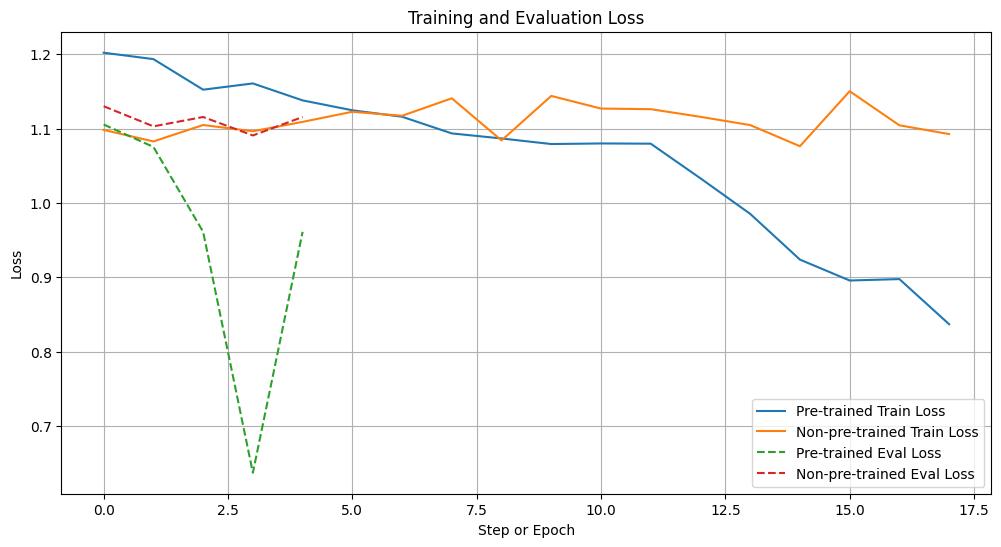

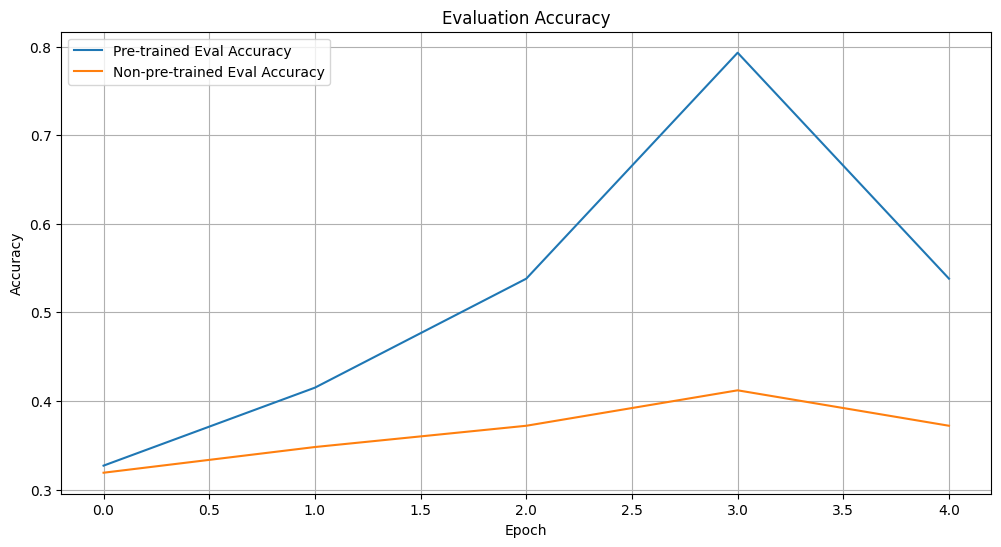

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os


# -------------------------------
# 7. 학습 로그 시각화 함수
# -------------------------------
def plot_loss_and_accuracy(pretrained_history, non_pretrained_history):


    # 디렉토리 생성 (없으면 생성)
    os.makedirs('./week03/plot', exist_ok=True)

    # Loss 값 추출
    pretrained_train_loss = [log['loss'] for log in pretrained_history if 'loss' in log]
    pretrained_eval_loss = [log['eval_loss'] for log in pretrained_history if 'eval_loss' in log]
    non_pretrained_train_loss = [log['loss'] for log in non_pretrained_history if 'loss' in log]
    non_pretrained_eval_loss = [log['eval_loss'] for log in non_pretrained_history if 'eval_loss' in log]

    # Accuracy 값 추출
    pretrained_eval_accuracy = [log['eval_accuracy'] for log in pretrained_history if 'eval_accuracy' in log]
    non_pretrained_eval_accuracy = [log['eval_accuracy'] for log in non_pretrained_history if 'eval_accuracy' in log]

    # Loss 그래프
    plt.figure(figsize=(12, 6))
    if pretrained_train_loss:
        plt.plot(range(len(pretrained_train_loss)), pretrained_train_loss, label='Pre-trained Train Loss')
    if non_pretrained_train_loss:
        plt.plot(range(len(non_pretrained_train_loss)), non_pretrained_train_loss, label='Non-pre-trained Train Loss')
    if pretrained_eval_loss:
        plt.plot(range(len(pretrained_eval_loss)), pretrained_eval_loss, label='Pre-trained Eval Loss', linestyle='--')
    if non_pretrained_eval_loss:
        plt.plot(range(len(non_pretrained_eval_loss)), non_pretrained_eval_loss, label='Non-pre-trained Eval Loss', linestyle='--')

    plt.title('Training and Evaluation Loss')
    plt.xlabel('Step or Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('./week03/plot/loss_curve.png')  # 저장

    plt.show()

    # Accuracy 그래프
    plt.figure(figsize=(12, 6))
    if pretrained_eval_accuracy:
        plt.plot(range(len(pretrained_eval_accuracy)), pretrained_eval_accuracy, label='Pre-trained Eval Accuracy')
    if non_pretrained_eval_accuracy:
        plt.plot(range(len(non_pretrained_eval_accuracy)), non_pretrained_eval_accuracy, label='Non-pre-trained Eval Accuracy')

    plt.title('Evaluation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig('./week03/plot/accuracy_plot.png')  # 저장

    plt.show()

# -------------------------------
# 8. 시각화 호출
# -------------------------------
plot_loss_and_accuracy(
    pre_trained_trainer.state.log_history,
    non_pre_trained_trainer.state.log_history
)